# Task 1A: Exploratory Data Analysis

This notebook explores the raw dataset "dataset_mood_smartphone.csv", aiming to get an overview of its properties and visualize them.

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)

df = pd.read_csv('dataset_mood_smartphone.csv', index_col=0, parse_dates=['time'])

## 1. Basic properties

In [45]:
print('Number of records :', len(df))
print('Number of users   :', df['id'].nunique())
print('Number of variables:', df['variable'].nunique())
print('Time range        :', df['time'].min(), '→', df['time'].max())
print('Study duration    :', (df['time'].max() - df['time'].min()).days, 'days')
print('\nMissing values per column:')
print(df.isna().sum())

Number of records : 376912
Number of users   : 27
Number of variables: 19
Time range        : 2014-02-17 07:00:52.197000 → 2014-06-09 00:00:00
Study duration    : 111 days

Missing values per column:
id            0
time          0
variable      0
value       202
dtype: int64


## 2. Variables overview

In [46]:
summary = df.groupby('variable')['value'].agg(
    n='count',
    n_missing=lambda x: x.isna().sum(),
    min='min', max='max', mean='mean', median='median', std='std'
).round(2).sort_values('n', ascending=False)
summary

,n,n_missing,min,max,mean,median,std
variable,,,,,,,
screen,96578,0,0.04,9867.01,75.34,20.04,253.82
appCat.builtin,91288,0,-82798.87,33960.25,18.54,4.04,415.99
appCat.communication,74276,0,0.01,9830.78,43.34,16.23,128.91
appCat.entertainment,27125,0,-0.01,32148.68,37.58,3.39,262.96
activity,22965,0,0.00,1.00,0.12,0.02,0.19
appCat.social,19145,0,0.09,30000.91,72.40,28.47,261.55
appCat.other,7650,0,0.01,3892.04,25.81,10.03,112.78
appCat.office,5642,0,0.00,32708.82,22.58,3.11,449.60
mood,5641,0,1.00,10.00,6.99,7.00,1.03


- The 19 variables group into three families: self-reported mood (`mood`, `circumplex.valence`, `circumplex.arousal`), phone usage durations in seconds (`screen` and the 11 `appCat.*` categories), and behavioral events (`activity`, `call`, `sms`).
- Some app-category durations reach tens of thousands of seconds in a single record, and two categories (`appCat.builtin`, `appCat.entertainment`) contain **negative values**. This is an anomaly worth flagging for later cleaning.

## 3. Coverage per user

In [47]:
df['date'] = df['time'].dt.date
coverage = df.groupby('id').agg(
    n_records=('value', 'size'),
    n_days=('date', 'nunique'),
    first_day=('time', 'min'),
    last_day=('time', 'max'),
)
coverage['span_days'] = (coverage['last_day'] - coverage['first_day']).dt.days
coverage

,n_records,n_days,first_day,last_day,span_days
id,,,,,
AS14.01,21999,72,2014-02-17 12:04:42.394,2014-05-05 10:00:00.000,76
AS14.02,14581,68,2014-02-17 07:00:52.197,2014-04-25 21:00:00.000,67
AS14.03,14425,77,2014-02-17 16:28:23.000,2014-05-08 05:00:00.000,79
AS14.05,15745,70,2014-02-18 13:07:45.496,2014-05-05 15:00:00.000,76
AS14.06,18092,74,2014-02-17 07:12:13.631,2014-05-08 09:00:00.000,80
AS14.07,16045,50,2014-03-17 21:03:46.401,2014-05-05 20:00:00.000,48
AS14.08,7902,67,2014-02-17 12:51:38.029,2014-05-05 15:00:00.000,77
AS14.09,10886,71,2014-02-17 10:47:29.664,2014-05-05 12:00:00.000,77
AS14.12,17311,67,2014-02-19 17:30:36.497,2014-05-05 18:00:00.000,75


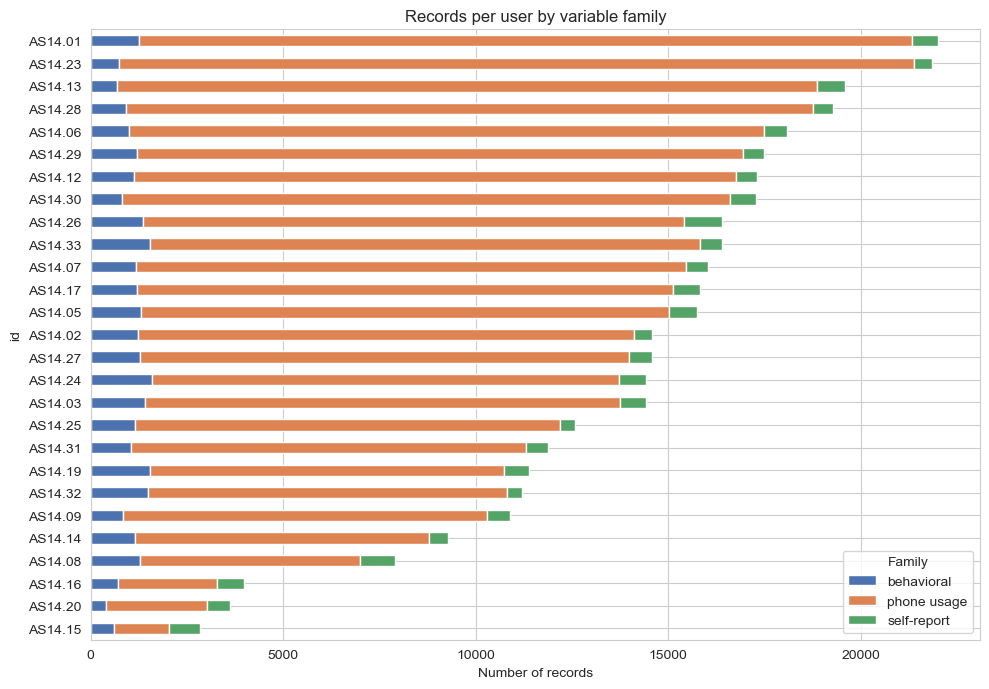

In [48]:
family_map = {
    'mood': 'self-report', 'circumplex.valence': 'self-report', 'circumplex.arousal': 'self-report',
    'screen': 'phone usage', **{v: 'phone usage' for v in df['variable'].unique() if v.startswith('appCat')},
    'activity': 'behavioral', 'call': 'behavioral', 'sms': 'behavioral',
}
df['family'] = df['variable'].map(family_map)

pivot = df.pivot_table(index='id', columns='family', values='value', aggfunc='size', fill_value=0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(10, 7))
pivot.plot(kind='barh', stacked=True, ax=ax,
           color=['#4C72B0', '#DD8452', '#55A467'])
ax.set_xlabel('Number of records')
ax.set_title('Records per user by variable family')
ax.legend(title='Family', loc='lower right')
plt.tight_layout()
plt.show()

## 4. Mood

### 4.1 Distribution

In [32]:
mood = df[df['variable'] == 'mood'].copy()
print('Mood records:', len(mood))
print(mood['value'].describe())

Mood records: 5641
count    5641.000000
mean        6.992555
std         1.032769
min         1.000000
25%         7.000000
50%         7.000000
75%         8.000000
max        10.000000
Name: value, dtype: float64


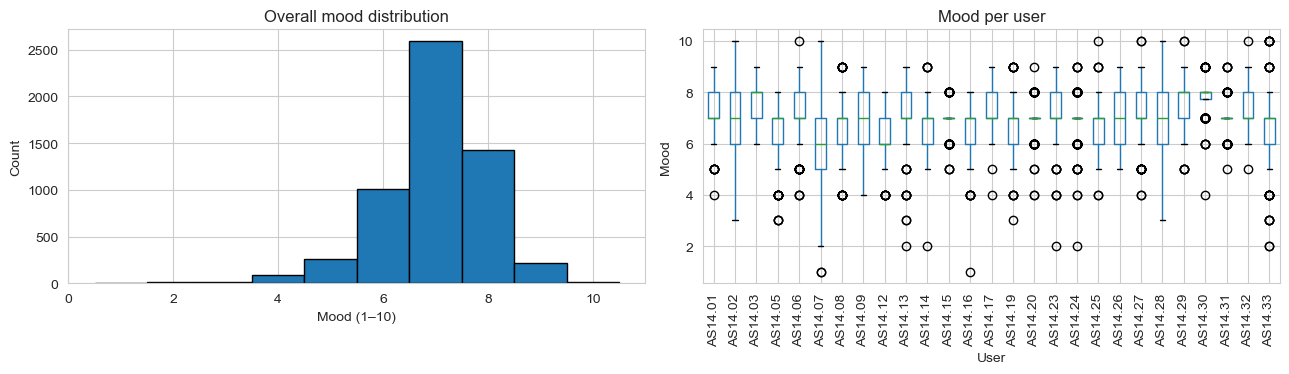

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(mood['value'].dropna(), bins=np.arange(0.5, 11, 1), edgecolor='black', color='tab:blue')
axes[0].set_xlabel('Mood (1–10)')
axes[0].set_ylabel('Count')
axes[0].set_title('Overall mood distribution')

mood.boxplot(column='value', by='id', ax=axes[1], rot=90)
axes[1].set_title('Mood per user')
axes[1].set_xlabel('User')
axes[1].set_ylabel('Mood')
plt.suptitle('')
plt.tight_layout()
plt.show()

- Mood is strongly concentrated around 7 and rarely dips below 5. 
- Between users, the medians differ by more than a full point on the scale, so we can see individual baselines clearly vary.

### 4.2 Temporal patterns

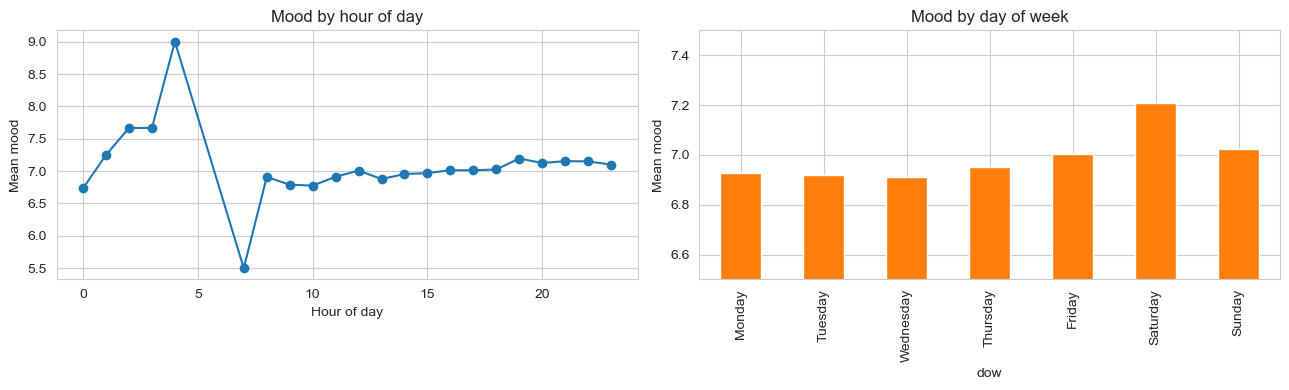

In [34]:
mood['hour'] = mood['time'].dt.hour
mood['dow'] = mood['time'].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

mood.groupby('hour')['value'].mean().plot(ax=axes[0], marker='o')
axes[0].set_xlabel('Hour of day')
axes[0].set_ylabel('Mean mood')
axes[0].set_title('Mood by hour of day')

order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
mood.groupby('dow')['value'].mean().reindex(order).plot(kind='bar', ax=axes[1], color='tab:orange')
axes[1].set_ylabel('Mean mood')
axes[1].set_title('Mood by day of week')
axes[1].set_ylim(6.5, 7.5)
plt.tight_layout()
plt.show()

## 5. Phone usage by app category

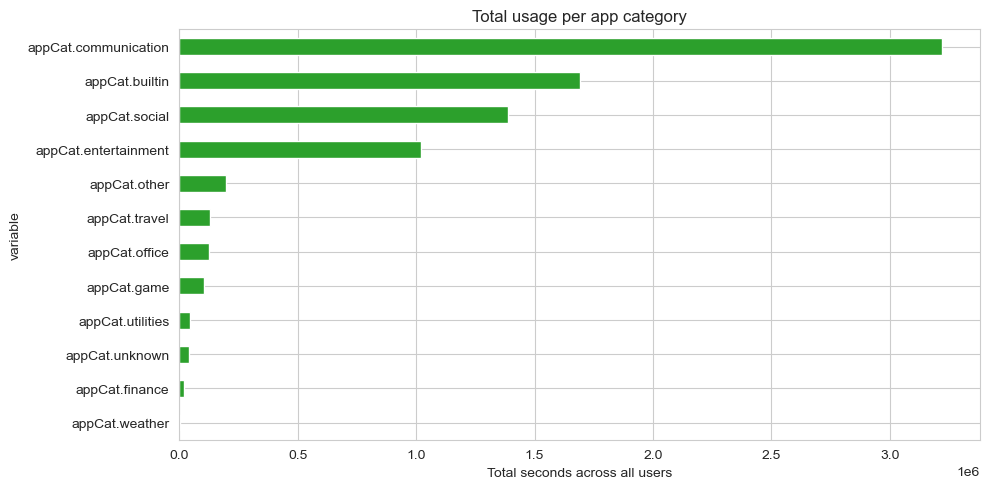

In [35]:
app_vars = [v for v in df['variable'].unique() if v.startswith('appCat')]
apps = df[df['variable'].isin(app_vars)]

fig, ax = plt.subplots(figsize=(10, 5))
apps.groupby('variable')['value'].sum().sort_values().plot(kind='barh', ax=ax, color='tab:green')
ax.set_xlabel('Total seconds across all users')
ax.set_title('Total usage per app category')
plt.tight_layout()
plt.show()

## 6. Correlations

In [36]:
# Aggregate: mean for self-reports, sum for durations/events
df['date'] = pd.to_datetime(df['time'].dt.date)
mean_vars = ['mood', 'circumplex.valence', 'circumplex.arousal', 'activity']
sum_vars = [v for v in df['variable'].unique() if v not in mean_vars]

agg_mean = (df[df['variable'].isin(mean_vars)]
            .pivot_table(index=['id','date'], columns='variable', values='value', aggfunc='mean'))
agg_sum  = (df[df['variable'].isin(sum_vars)]
            .pivot_table(index=['id','date'], columns='variable', values='value', aggfunc='sum'))

daily = agg_mean.join(agg_sum, how='outer').reset_index()

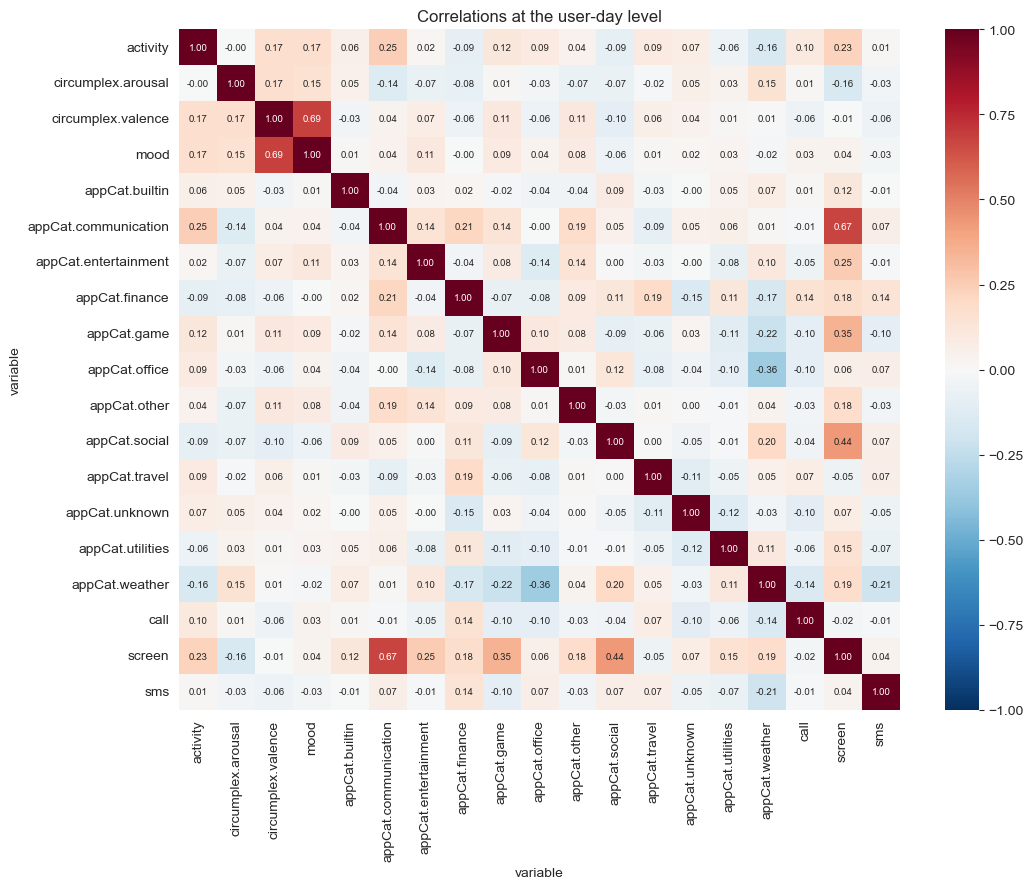

In [37]:
corr = daily.drop(columns=['id','date']).corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size': 7}, ax=ax)
ax.set_title('Correlations at the user-day level')
plt.tight_layout()
plt.show()